# 12 · Differentiable Robotics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/boelnasr/ManipulaPy/blob/notebooks/tutorials/notebooks/12_differentiable_robotics.ipynb)

> **ManipulaPy teaching course — advanced appendix.** This notebook is not a step in the core sequence; it is a deep dive on one v1.4 feature. It assumes notebooks 01–06 and nothing after them. Running robot: Franka Panda.

Every notebook so far computed a **value**: a pose (02), a Jacobian (03), a joint solution (04), a torque (05), a manipulability score (06). This one computes **derivatives of those values with respect to whatever they depend on** — and gets them exactly, from the same code that computed the value, without writing a single extra line of calculus.

That is worth having because most of the hard problems in robotics are optimisation problems in disguise:

- **inverse kinematics** minimises a pose error over joint angles (notebook 04 did it with a hand-derived Jacobian — here the derivative is free, so the objective can be *anything* differentiable);
- **trajectory optimisation** minimises energy, jerk or time over a whole path, subject to the dynamics of notebook 05;
- **system identification and sim-to-real** fit link masses, inertias and friction to measured torques, which needs $\partial\tau/\partial(\text{parameters})$;
- **learning** puts a neural network next to the robot model and backpropagates through both.

All four need gradients. The classic options are to derive them by hand (accurate, laborious, and wrong the moment the model changes) or to use finite differences (easy, but $n+1$ model evaluations and a step size that trades truncation error against roundoff). **Automatic differentiation** is the third option: the derivative is assembled from the chain rule applied to the operations the code actually executed, so it is exact to machine precision and costs a small constant factor over the value itself.

ManipulaPy v1.4 makes this possible with the **unified backend system**. The same kinematics and dynamics code runs on NumPy, CuPy, PyTorch or JAX; under the two autodiff backends the array operations become differentiable ones, so `jax.jacrev(robot.forward_kinematics)` just works. This notebook uses JAX.

### Running on Colab or another cloud platform?

The next cell bootstraps the environment on Google Colab. It is a **no-op when you run locally** from a clone of the repo. JAX is preinstalled on Colab; locally you need `pip install ManipulaPy[jax-cpu]` (or `[jax-cuda]`).

In [1]:
# Cloud bootstrap (no-op when running locally from the repo).
import sys
if "google.colab" in sys.modules:
    !git clone -q https://github.com/boelnasr/ManipulaPy.git
    %cd ManipulaPy/notebooks
    !pip install -q -e ..
    print("Colab setup complete.")

In [2]:
import os, sys, time
sys.path.insert(0, os.path.join(os.getcwd(), "_shared"))
from tikz import setup_pgf, embed_pgf_fig
import numpy as np
from helpers import load_panda, HOME, N_JOINTS
from ManipulaPy import utils
from ManipulaPy.backend import use_backend, get_backend
import jax
import jax.numpy as jnp
np.set_printoptions(precision=4, suppress=True)

sm, dyn = load_panda()
print("Panda loaded | JAX", jax.__version__, "| devices:", jax.devices())

🤖 ManipulaPy v1.4.0 loaded (lazy imports enabled)
   💡 Use ManipulaPy.check_dependencies() to see available features


pybullet build time: Jan 29 2025 23:16:28


Panda loaded | JAX 0.6.2 | devices: [CpuDevice(id=0)]


## 1. One API, four backends

`ManipulaPy.backend` holds exactly one **active backend** for the process. Every numerical module dispatches its array operations through it instead of importing NumPy directly, so switching the backend switches what `forward_kinematics` computes *with* — not what it computes.

There are two ways in. `set_backend("jax")` switches globally; `use_backend("jax")` is a context manager that always restores the previous backend on exit, including when the block raises. Prefer the context manager: it is very easy to leave a process in a surprising state otherwise. Selection is explicit opt-in — ManipulaPy never sniffs your environment and silently promotes you to a GPU backend.

The point of the next cell is that **the math is unchanged**. The same call, on the same joint angles, returns the same pose to the last bit; only the array type differs.

In [3]:
T_numpy = sm.forward_kinematics(HOME)          # default backend: NumPy

with use_backend("jax"):
    q_jax = jnp.asarray(HOME)
    T_jax = sm.forward_kinematics(q_jax)
    inside = type(T_jax).__name__
    dtype_inside = q_jax.dtype

print("NumPy backend ->", type(T_numpy).__name__, T_numpy.dtype)
print("JAX   backend ->", inside, dtype_inside)
print("max |T_numpy - T_jax| = %.3e" % np.max(np.abs(np.asarray(T_jax) - T_numpy)))
assert np.allclose(np.asarray(T_jax), T_numpy, rtol=0, atol=1e-12)
# use_backend restored the default on exit
assert type(sm.forward_kinematics(HOME)).__name__ == "ndarray"

NumPy backend -> ndarray float64
JAX   backend -> ArrayImpl float64
max |T_numpy - T_jax| = 2.220e-16


> **float64 and JAX.** JAX defaults every float array to `float32`, which would quietly halve the precision of everything in this course. ManipulaPy's JAX backend therefore calls `jax.config.update("jax_enable_x64", True)` when it is first requested — which is why `q_jax` above is `float64`. Two consequences worth knowing: the flag is **process-global JAX state** and is not reverted when the `use_backend` block exits, and any `jnp` array you build *before* the first `use_backend("jax")` will still be `float32`. Build your arrays inside the block.

## 2. $\partial T/\partial\theta$ — and why it is the Jacobian

`jax.jacrev(f)(x)` returns the full Jacobian of `f` at `x` by reverse-mode differentiation. Applied to forward kinematics, `f` maps $7$ joint angles to a $4\times4$ pose, so the result has shape $(4,4,7)$: one $4\times4$ matrix $\partial T/\partial\theta_i$ per joint.

These are **real gradients**, not finite differences — no step size, no $n+1$ evaluations, no truncation error. The derivative is built from the chain rule applied to the exact sequence of matrix exponentials and products that `forward_kinematics` executed.

In [4]:
with use_backend("jax"):
    q = jnp.asarray(HOME)
    dT = jax.jacrev(sm.forward_kinematics)(q)
    dT = np.asarray(dT)

print("dT/dtheta shape:", dT.shape, " (4x4 pose derivative per joint)")
print("\ndT/dtheta_1 (joint 1 rotates the whole arm about the base z axis):")
print(dT[:, :, 0])

dT/dtheta shape: (4, 4, 7)  (4x4 pose derivative per joint)

dT/dtheta_1 (joint 1 rotates the whole arm about the base z axis):
[[-0.0004  1.      0.      0.    ]
 [ 1.      0.0004  0.      0.4649]
 [ 0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.    ]]


### The satisfying part: this *is* the space Jacobian

ManipulaPy already computes a Jacobian analytically (notebook 03), from the product-of-exponentials structure and a hand-derived formula. Autodiff has just computed a derivative of the same map by a completely different route. They must agree — and checking that they do is both a genuinely satisfying result and a real correctness test of both implementations at once.

They are not the *same array*, because they are different parameterisations of the same derivative. The space Jacobian's column $J_i$ is the end-effector twist produced by unit rate on joint $i$, expressed in the space frame, and the twist relates to the pose derivative through

$$\frac{\partial T}{\partial\theta_i} = [\mathcal{J}_i]\, T,
\qquad\text{equivalently}\qquad
\mathcal{J}_i = \operatorname{vee}\!\left(\frac{\partial T}{\partial\theta_i}\,T^{-1}\right),$$

where $[\cdot]$ is the $4\times4$ $se(3)$ matrix form of a twist (`utils.VecTose3`) and $\operatorname{vee}$ its inverse (`utils.se3ToVec`) — both from notebook 01. So the check is: multiply each analytic Jacobian column into $se(3)$ form, apply it to $T$, and compare with what `jacrev` returned.

In [5]:
J_analytic = sm.jacobian(HOME, frame='space')                  # 6 x 7, notebook 03

# Prediction from the analytic Jacobian: dT/dtheta_i = [J_i] T
dT_predicted = np.stack(
    [utils.VecTose3(J_analytic[:, i]) @ T_numpy for i in range(N_JOINTS)], axis=-1)

# ...and the same identity read the other way: recover J from the autodiff result.
T_inv = np.linalg.inv(T_numpy)
J_autodiff = np.stack(
    [utils.se3ToVec(dT[:, :, i] @ T_inv) for i in range(N_JOINTS)], axis=1)

print("max |dT_autodiff - [J_i] T| = %.3e" % np.max(np.abs(dT - dT_predicted)))
print("max |J_autodiff  - J_analytic| = %.3e" % np.max(np.abs(J_autodiff - J_analytic)))
assert np.allclose(dT, dT_predicted, rtol=0, atol=1e-12)
assert np.allclose(J_autodiff, J_analytic, rtol=0, atol=1e-12)

# The body Jacobian satisfies the mirror identity, dT/dtheta_i = T [J^b_i].
J_body = sm.jacobian(HOME, frame='body')
dT_body = np.stack(
    [T_numpy @ utils.VecTose3(J_body[:, i]) for i in range(N_JOINTS)], axis=-1)
print("max |dT_autodiff - T [J^b_i]| = %.3e" % np.max(np.abs(dT - dT_body)))
assert np.allclose(dT, dT_body, rtol=0, atol=1e-12)

max |dT_autodiff - [J_i] T| = 3.331e-16
max |J_autodiff  - J_analytic| = 3.331e-16
max |dT_autodiff - T [J^b_i]| = 3.331e-16


Agreement to $10^{-16}$ — the two derivations are identical to the last bit of double precision, which is as close to a proof as floating point gets. The figure below shows both $6\times7$ matrices and their difference; the residual panel is plotted on a log scale precisely because there is nothing there to see on a linear one.

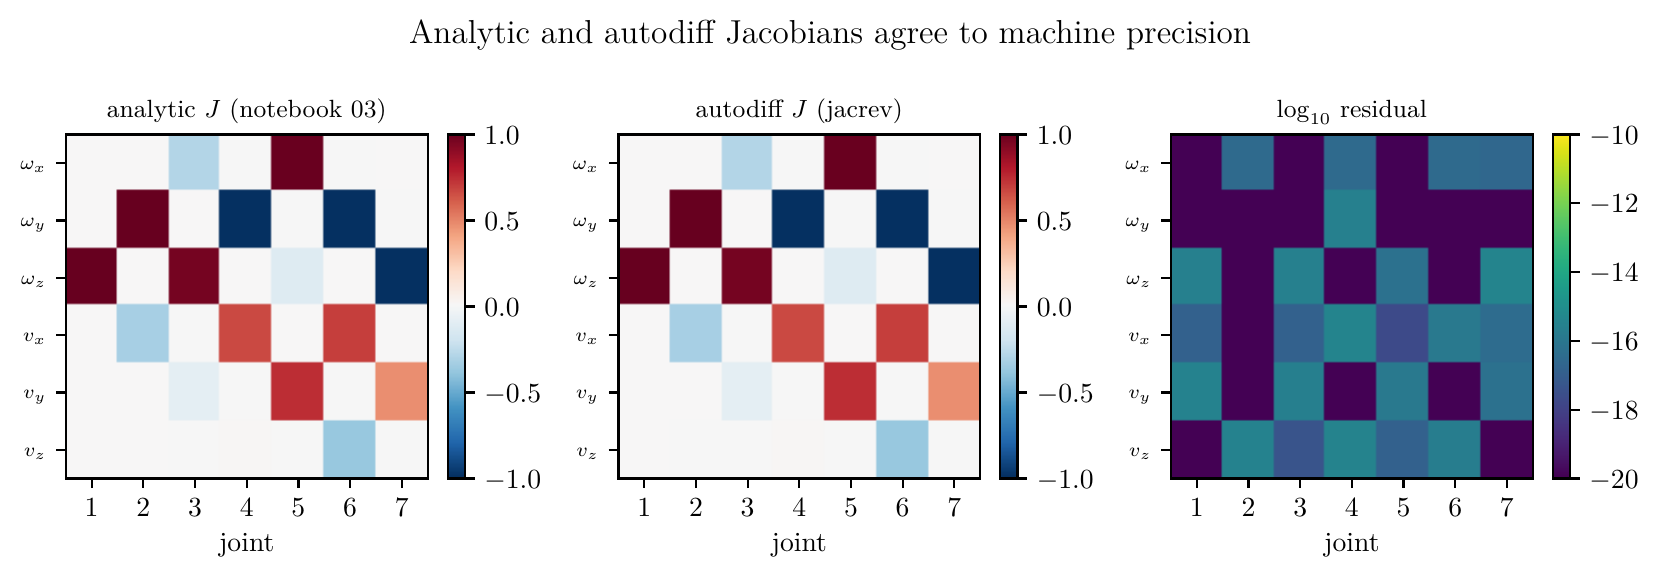

In [6]:
resid = np.abs(J_autodiff - J_analytic)
vmax = np.max(np.abs(J_analytic))

plt = setup_pgf()
fig, axes = plt.subplots(1, 3, figsize=(8.4, 2.9))
for ax, (M, title, kw) in zip(axes, [
        (J_analytic, 'analytic $J$ (notebook 03)',
         dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax)),
        (J_autodiff, 'autodiff $J$ (jacrev)',
         dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax)),
        (np.log10(resid + 1e-20), '$\\log_{10}$ residual',
         dict(cmap='viridis', vmin=-20, vmax=-10))]):
    im = ax.imshow(M, aspect='auto', **kw)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('joint'); ax.set_xticks(range(N_JOINTS))
    ax.set_xticklabels(range(1, N_JOINTS + 1))
    ax.set_yticks(range(6))
    ax.set_yticklabels(['$\\omega_x$', '$\\omega_y$', '$\\omega_z$',
                        '$v_x$', '$v_y$', '$v_z$'], fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Analytic and autodiff Jacobians agree to machine precision')
fig.tight_layout()
embed_pgf_fig(fig, name="autodiff_vs_analytic_jacobian")

## 3. Gradient-based inverse kinematics

Notebook 04 solved IK with Newton–Raphson on the analytic Jacobian. With autodiff we can instead write down a **scalar cost** and let the framework differentiate it. The natural cost is the squared norm of the twist that carries the current pose to the goal — the $se(3)$ logarithm from notebook 01, which handles position and orientation in one consistent quantity:

$$L(\theta)=\bigl\|\log\bigl(T(\theta)^{-1}T_{\text{goal}}\bigr)\bigr\|^2 .$$

`jax.value_and_grad` returns $L$ and $\nabla_\theta L$ together (the gradient costs about as much as the value in reverse mode), and `jax.jit` compiles the whole step once so the loop runs at compiled speed. Then it is plain gradient descent.

Note what had to be true for this to work: the $se(3)$ log is a **branch point** at $\theta=0$ and $\theta=\pi$, and a naive implementation returns a perfectly good value there while leaking `NaN` into the gradient. ManipulaPy's `MatrixLog6` is conditioned so both stay finite and correct — several defects of exactly that shape were found and fixed while building this contract.

In [7]:
q_goal = HOME + np.array([0.3, 0.2, -0.25, 0.4, 0.1, -0.3, 0.2])
T_goal = sm.forward_kinematics(q_goal)

with use_backend("jax"):
    T_goal_jax = jnp.asarray(T_goal)

    def pose_cost(q):
        T = sm.forward_kinematics(q)
        twist = utils.se3ToVec(utils.MatrixLog6(jnp.linalg.solve(T, T_goal_jax)))
        return jnp.sum(twist ** 2)

    step_fn = jax.jit(jax.value_and_grad(pose_cost))   # compiles on first call
    q = jnp.asarray(HOME)
    history = []
    t0 = time.time()
    for _ in range(600):
        value, grad = step_fn(q)
        history.append(float(value))
        q = q - 0.2 * grad                              # plain gradient descent
    elapsed = time.time() - t0
    q_solved = np.asarray(q)

T_solved = sm.forward_kinematics(q_solved)
print("600 descent steps in %.2f s" % elapsed)
print("cost  %.3e -> %.3e" % (history[0], history[-1]))
print("position error  %.3e m" % np.linalg.norm(T_solved[:3, 3] - T_goal[:3, 3]))
print("rotation error  %.3e"   % np.linalg.norm(T_solved[:3, :3] - T_goal[:3, :3]))
assert history[-1] < 1e-6
assert np.linalg.norm(T_solved[:3, 3] - T_goal[:3, 3]) < 1e-3

600 descent steps in 0.72 s
cost  5.107e-02 -> 4.446e-08
position error  2.035e-04 m
rotation error  6.680e-05


### The real payoff: an objective you could not hand-differentiate

Taken alone, that solver is *worse* than notebook 04's — plain gradient descent converges linearly where Newton's method converges quadratically, and it needed 600 steps to reach what Newton reaches in a handful. Autodiff did not make IK faster.

What it made possible is **changing the objective**. Add a term rewarding manipulability $w=\sqrt{\det(JJ^{\top})}$ (notebook 06) and the solver looks for a solution that is not just correct but *well-conditioned* — away from the singularities that would wreck the controller:

$$L_\lambda(\theta)=\bigl\|\log(T^{-1}T_{\text{goal}})\bigr\|^2 - \lambda\,w(\theta).$$

Differentiating $w$ by hand means differentiating a determinant of a product of matrix exponentials. Here it is one extra line, and the gradient is still exact. Sweeping $\lambda$ traces the trade-off: buy conditioning, pay accuracy.

In [8]:
lambdas = [0.0, 0.05, 0.1, 0.2, 0.4, 0.8, 1.6]
pose_costs, manips = [], []

with use_backend("jax"):
    T_goal_jax = jnp.asarray(T_goal)

    def pose_cost(q):
        twist = utils.se3ToVec(
            utils.MatrixLog6(jnp.linalg.solve(sm.forward_kinematics(q), T_goal_jax)))
        return jnp.sum(twist ** 2)

    def manipulability(q):
        J = sm.jacobian(q)
        return jnp.sqrt(jnp.linalg.det(J @ J.T))

    w_home = float(manipulability(jnp.asarray(HOME)))
    for lam in lambdas:
        step_fn = jax.jit(jax.value_and_grad(
            lambda q, l=lam: pose_cost(q) - l * manipulability(q)))
        q = jnp.asarray(HOME)
        for _ in range(600):
            _, grad = step_fn(q)
            q = q - 0.2 * grad
        pose_costs.append(float(pose_cost(q)))
        manips.append(float(manipulability(q)))

print("w at HOME = %.5f" % w_home)
for lam, c, w in zip(lambdas, pose_costs, manips):
    print("lambda %5.2f -> pose cost %.3e   manipulability w %.5f" % (lam, c, w))
# More weight on w buys conditioning and costs pose accuracy, monotonically.
assert manips[-1] > manips[0]
assert pose_costs[-1] > pose_costs[0]

w at HOME = 0.09416
lambda  0.00 -> pose cost 4.365e-08   manipulability w 0.08749
lambda  0.05 -> pose cost 3.258e-05   manipulability w 0.08880
lambda  0.10 -> pose cost 1.062e-04   manipulability w 0.08979
lambda  0.20 -> pose cost 3.097e-04   manipulability w 0.09118
lambda  0.40 -> pose cost 7.673e-04   manipulability w 0.09277
lambda  0.80 -> pose cost 1.586e-03   manipulability w 0.09420
lambda  1.60 -> pose cost 2.863e-03   manipulability w 0.09532


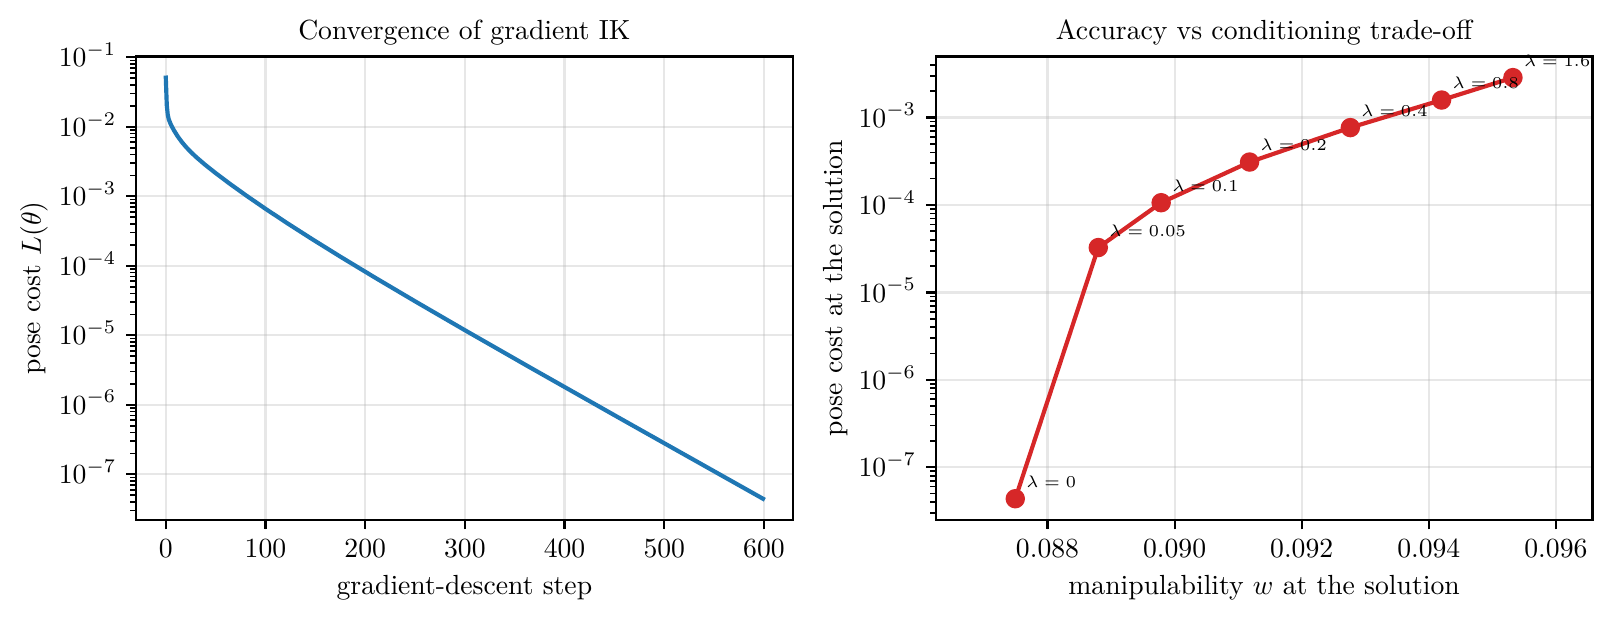

In [9]:
plt = setup_pgf()
fig, (axL, axR) = plt.subplots(1, 2, figsize=(8.2, 3.2))

axL.semilogy(history, color='tab:blue')
axL.set_xlabel('gradient-descent step'); axL.set_ylabel('pose cost $L(\\theta)$')
axL.set_title('Convergence of gradient IK', fontsize=10)
axL.grid(alpha=0.3)

axR.plot(manips, pose_costs, 'o-', color='tab:red')
for lam, c, w in zip(lambdas, pose_costs, manips):
    axR.annotate('$\\lambda=%g$' % lam, (w, c), fontsize=6,
                 textcoords='offset points', xytext=(4, 4))
axR.set_yscale('log')
axR.margins(x=0.16)
axR.set_xlabel('manipulability $w$ at the solution')
axR.set_ylabel('pose cost at the solution')
axR.set_title('Accuracy vs conditioning trade-off', fontsize=10)
axR.grid(alpha=0.3)
fig.tight_layout()
embed_pgf_fig(fig, name="gradient_ik")

## 4. $\partial\tau/\partial\theta$ — gradients through the dynamics

The differentiable contract covers `dynamics` too, so the inverse dynamics of notebook 05 — mass matrix, Coriolis terms, gravity, end-effector wrench, the whole $\tau=M(\theta)\ddot\theta+c(\theta,\dot\theta)+g(\theta)+J^{\top}F$ — is differentiable end to end.

This is the derivative that optimal control needs. Direct-collocation and shooting methods linearise the dynamics about the current iterate at every knot point; iLQR and DDP need exactly these partials to build their local quadratic models. Hand-deriving $\partial\tau/\partial\theta$ for a 7-DOF arm is a genuinely unpleasant piece of algebra, and finite-differencing it costs $2n$ full RNEA evaluations with a step size you have to tune.

Evaluate it at rest — zero velocity, zero acceleration, no tip wrench — so $\tau$ is pure gravity compensation and the derivative has a clean interpretation.

In [10]:
g_vec = np.array([0.0, 0.0, -9.81])
zeros_n, zero_wrench = np.zeros(N_JOINTS), np.zeros(6)

tau_numpy = dyn.inverse_dynamics(HOME, zeros_n, zeros_n, g_vec, zero_wrench)
print("gravity torques at HOME (Nm):", tau_numpy)

with use_backend("jax"):
    args = (jnp.zeros(N_JOINTS), jnp.zeros(N_JOINTS),
            jnp.asarray(g_vec), jnp.zeros(6))

    def torque(q):
        return dyn.inverse_dynamics(q, *args)

    t0 = time.time()
    dtau = np.asarray(jax.jacrev(torque)(jnp.asarray(HOME)))
    print('jacrev of inverse dynamics: %.1f s (eager, see section 5)' % (time.time() - t0))

print("dtau/dtheta shape:", dtau.shape)

gravity torques at HOME (Nm): [ -0.     -10.8952   0.      12.383    0.       0.8633  -0.    ]


jacrev of inverse dynamics: 20.7 s (eager, see section 5)
dtau/dtheta shape: (7, 7)


Two checks. First against **central differences** on the NumPy backend — an independent route to the same quantity, and the reference this contract is tested against in the library's own suite.

Second, a structural one. At rest the torque is the gradient of the potential energy, $\tau=\partial U/\partial\theta$, so $\partial\tau/\partial\theta$ is the **Hessian** $\partial^2U/\partial\theta^2$ — and Hessians are symmetric. Nothing in the code enforces that; it falls out of the derivative being right. This is the **gravitational stiffness matrix**, and its eigenvalues say how hard gravity pulls back along each mode.

It is also almost empty, which is informative rather than suspicious: at `HOME` only joints 2–5 have any gravitational coupling at all. Joint 1's screw axis is vertical, parallel to gravity, so turning it carries the whole arm around the gravity vector without changing a single gravity torque — one of the zero eigenvalues.

In [11]:
def central_difference_jacobian(f, x, h=1e-6):
    cols = []
    for i in range(x.size):
        e = np.zeros_like(x); e[i] = h
        cols.append((f(x + e) - f(x - e)) / (2 * h))
    return np.stack(cols, axis=1)

dtau_fd = central_difference_jacobian(
    lambda x: dyn.inverse_dynamics(x, zeros_n, zeros_n, g_vec, zero_wrench), HOME)

print("max |autodiff - central difference| = %.3e" % np.max(np.abs(dtau - dtau_fd)))
print("asymmetry  max |A - A^T|            = %.3e" % np.max(np.abs(dtau - dtau.T)))
assert np.allclose(dtau, dtau_fd, rtol=1e-5, atol=1e-6)
assert np.allclose(dtau, dtau.T, rtol=0, atol=1e-9)

eigs = np.linalg.eigvalsh(dtau)
print("gravitational stiffness eigenvalues (Nm/rad):", np.round(eigs, 3))

max |autodiff - central difference| = 3.830e-09
asymmetry  max |A - A^T|            = 9.326e-15
gravitational stiffness eigenvalues (Nm/rad): [-16.773  -4.536  -0.894  -0.11   -0.     -0.      0.   ]


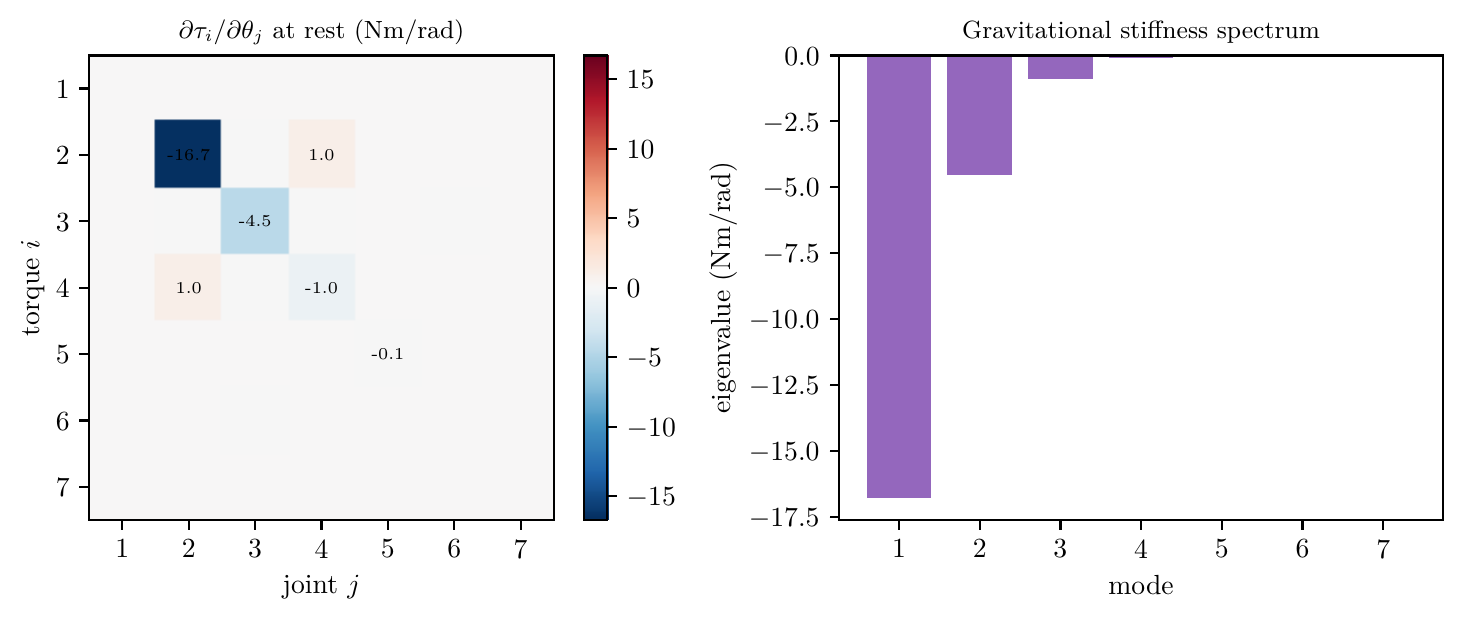

In [12]:
scale = np.max(np.abs(dtau))
plt = setup_pgf()
fig, (axA, axB) = plt.subplots(1, 2, figsize=(7.8, 3.2))
im = axA.imshow(dtau, cmap='RdBu_r', vmin=-scale, vmax=scale)
axA.set_title('$\\partial\\tau_i/\\partial\\theta_j$ at rest (Nm/rad)', fontsize=9)
axA.set_xlabel('joint $j$'); axA.set_ylabel('torque $i$')
axA.set_xticks(range(N_JOINTS)); axA.set_xticklabels(range(1, N_JOINTS + 1))
axA.set_yticks(range(N_JOINTS)); axA.set_yticklabels(range(1, N_JOINTS + 1))
for i in range(N_JOINTS):                  # only a few entries are non-negligible
    for j in range(N_JOINTS):
        if abs(dtau[i, j]) > 0.05:
            axA.text(j, i, '%.1f' % dtau[i, j], ha='center', va='center', fontsize=6)
fig.colorbar(im, ax=axA, fraction=0.046)

axB.bar(range(1, N_JOINTS + 1), eigs, color='tab:purple')
axB.set_xticks(range(1, N_JOINTS + 1))
axB.axhline(0.0, color='k', lw=0.6)
axB.set_xlabel('mode'); axB.set_ylabel('eigenvalue (Nm/rad)')
axB.set_title('Gravitational stiffness spectrum', fontsize=9)
fig.tight_layout()
embed_pgf_fig(fig, name="inverse_dynamics_gradient")

## 5. Where this stops working — read this part

Two limits matter in practice, and both are easy to walk into.

### 5a. The differentiable contract covers core math only

Gradients are guaranteed for **`utils`, `kinematics`, `dynamics` and `singularity`** — that is the whole of what this notebook differentiated. Every other module *runs* under all four backends, but through **host-boundary conversion**: arrays are converted to NumPy, the existing implementation runs, and the result is converted back. Those paths are portable, not differentiable.

| Host-bound | Why |
|---|---|
| `trac_ik` SLSQP solve | SciPy optimiser, host-only |
| `sim` (PyBullet) | external physics engine |
| `potential_field` convex hull | SciPy/Qhull, host-only |
| `path_planning` / `cuda_kernels` | Numba CUDA kernels take device pointers |

The good news is that this fails **loudly**. JAX cannot convert a tracer to a NumPy array, so differentiating through a host boundary raises `TracerArrayConversionError` rather than silently handing back a wrong gradient — which is exactly the failure mode you want.

In [13]:
from ManipulaPy.path_planning import TrajectoryPlanning
from helpers import PANDA_URDF

planner = TrajectoryPlanning(sm, PANDA_URDF, dyn,
                             joint_limits=[(-3.0, 3.0)] * N_JOINTS)

def path_length(q):
    traj = planner.joint_trajectory(q, q + 0.1, 1.0, 10, 5)
    return jnp.sum(jnp.asarray(traj['positions']) ** 2)

try:
    with use_backend("jax"):
        jax.grad(path_length)(jnp.asarray(HOME))
    raise AssertionError("expected the host boundary to refuse the tracer")
except jax.errors.TracerArrayConversionError as exc:
    print("refused, as documented:", str(exc).split("\n")[0])

❌ CUDA not available: CUDA driver probe failed (unavailable or driver crash) - using CPU


refused, as documented: The numpy.ndarray conversion method __array__() was called on traced array with shape float64[7]


### 5b. Eager JAX is slower than NumPy — much slower

Per-call dispatch overhead dominates at robot-sized array shapes. A single forward kinematics call costs a fraction of a millisecond in NumPy; the same call under eager JAX costs tens of times more, because each of the dozens of small operations pays JAX's dispatch cost with nothing to amortise it against. **This is a property of eager JAX, not of ManipulaPy**, and it is why the library's default backend stays NumPy.

JAX pays off when the overhead is compiled away: `jit` traces the whole computation once and hands XLA a single fused program, and `vmap` does the same for a batch. The four columns below are the same forward kinematics.

(Timings call `block_until_ready()`. JAX dispatches asynchronously, so timing without it measures how fast Python can queue work, not how fast the work runs.)

In [14]:
REPEATS, BATCH = 100, 256
rng = np.random.default_rng(0)
Q_batch = HOME + 0.1 * rng.normal(size=(BATCH, N_JOINTS))

def bench(fn, n=REPEATS):
    fn()                                  # warm up / compile
    t0 = time.time()
    for _ in range(n):
        fn()
    return (time.time() - t0) / n * 1e3    # ms per call

ms_numpy = bench(lambda: sm.forward_kinematics(HOME))
ms_numpy_batch = bench(lambda: [sm.forward_kinematics(q) for q in Q_batch], n=5) / BATCH

with use_backend("jax"):
    q = jnp.asarray(HOME)
    Qj = jnp.asarray(Q_batch)
    fk_jit = jax.jit(sm.forward_kinematics)
    fk_batch = jax.jit(jax.vmap(sm.forward_kinematics))
    ms_eager = bench(lambda: sm.forward_kinematics(q).block_until_ready())
    ms_jit = bench(lambda: fk_jit(q).block_until_ready())
    ms_vmap = bench(lambda: fk_batch(Qj).block_until_ready()) / BATCH

labels = ['NumPy\n(default)', 'JAX eager', 'JAX jit', 'JAX jit+vmap\n(%d poses)' % BATCH]
times = [ms_numpy, ms_eager, ms_jit, ms_vmap]
for lab, t in zip(labels, times):
    print("%-22s %8.4f ms per pose" % (lab.replace("\n", " "), t))
print("\nJAX eager is %.0fx slower than NumPy; jit is %.1fx faster; "
      "jit+vmap is %.0fx faster." % (ms_eager / ms_numpy, ms_numpy / ms_jit,
                                     ms_numpy_batch / ms_vmap))
assert ms_eager > ms_numpy      # eager dispatch really does cost more
assert ms_vmap < ms_numpy       # batching really does win it back

NumPy (default)          0.1773 ms per pose
JAX eager               12.9733 ms per pose
JAX jit                  0.0122 ms per pose
JAX jit+vmap (256 poses)   0.0014 ms per pose

JAX eager is 73x slower than NumPy; jit is 14.5x faster; jit+vmap is 133x faster.


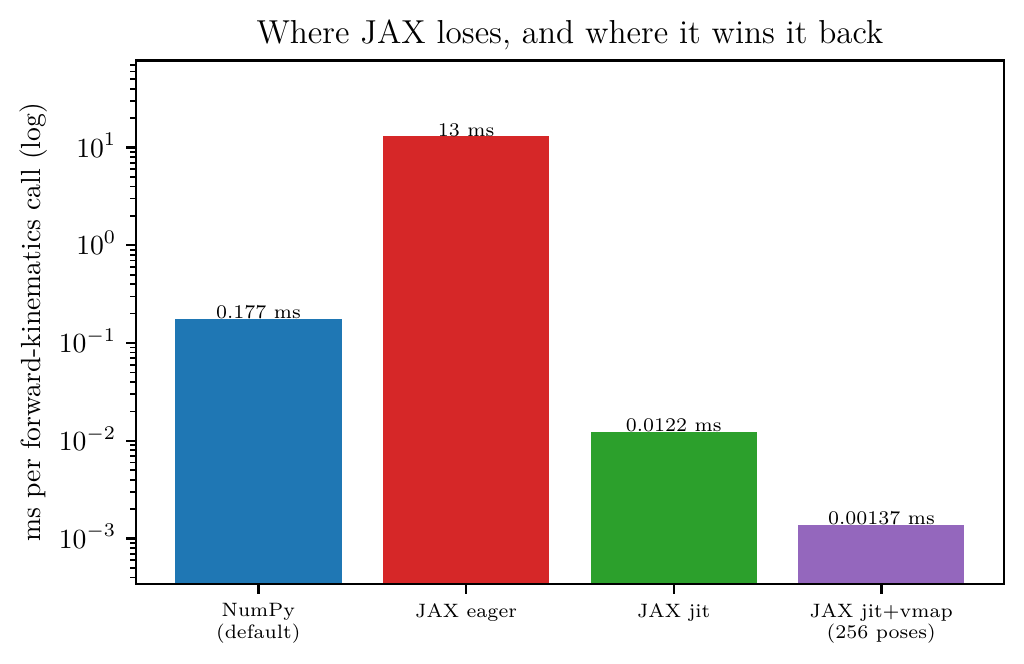

In [15]:
plt = setup_pgf()
fig, ax = plt.subplots(figsize=(5.6, 3.4))
colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:purple']
ax.bar(range(4), times, color=colors)
ax.set_yscale('log')
ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel('ms per forward-kinematics call (log)')
ax.set_title('Where JAX loses, and where it wins it back')
for i, t in enumerate(times):
    ax.annotate('%.3g ms' % t, (i, t), ha='center', va='bottom', fontsize=7)
ax.set_ylim(min(times) / 4, max(times) * 6)
embed_pgf_fig(fig, name="backend_timing")

Three consequences worth carrying away:

1. **Compilation is not free.** `jit` on forward kinematics compiles in a fraction of a second, but compile time grows with the size of the traced graph. `jit(jacrev(inverse_dynamics))` for this 7-DOF arm took over seven minutes to compile on the machine this notebook was built on, against about 20 seconds to run eagerly — which is why section 4 does not `jit` it. Measure before you compile.
2. **Any time-budgeted algorithm behaves differently under JAX.** `TracIKSolver.solve` takes a `timeout` (default 0.2 s) and will not converge inside it on the JAX backend. With a wider budget it reaches the same answer as NumPy: `solver.solve(T_desired, theta_init, timeout=5.0)`. The default is deliberately unchanged, because raising it for one backend would slow failure detection for everyone else.
3. **Pick the backend for the job.** NumPy for one-shot calls and interactive work (the default, and the frozen public return contract); JAX or PyTorch when you need gradients or a compiled batch; CuPy for raw throughput on large arrays. The trajectory-generation CUDA kernels run regardless of the active backend.

## Smoke test

Asserts the key invariants of this notebook in one cell.

In [16]:
sm2, dyn2 = load_panda()
T_ref = sm2.forward_kinematics(HOME)
J_ref = sm2.jacobian(HOME, frame='space')

with use_backend("jax"):
    qj = jnp.asarray(HOME)
    # 1. Switching the backend does not change the value.
    assert np.allclose(np.asarray(sm2.forward_kinematics(qj)), T_ref, atol=1e-12)
    # 2. jacrev of FK reproduces the analytic space Jacobian exactly.
    dT2 = np.asarray(jax.jacrev(sm2.forward_kinematics)(qj))
    Ti = np.linalg.inv(T_ref)
    J2 = np.stack([utils.se3ToVec(dT2[:, :, i] @ Ti) for i in range(N_JOINTS)], axis=1)
    assert np.allclose(J2, J_ref, rtol=0, atol=1e-12)
    # 3. Inverse dynamics is differentiable and its gravity block is symmetric.
    z = jnp.zeros(N_JOINTS)
    d2 = np.asarray(jax.jacrev(
        lambda v: dyn2.inverse_dynamics(v, z, z, jnp.asarray(g_vec), jnp.zeros(6)))(qj))
    assert np.all(np.isfinite(d2))
    assert np.allclose(d2, d2.T, atol=1e-9)

# 4. use_backend restored NumPy on exit.
assert type(sm2.forward_kinematics(HOME)).__name__ == "ndarray"
print("nb12 differentiable robotics: smoke OK")

nb12 differentiable robotics: smoke OK


## Try it

1. Replace gradient descent in section 3 with **Gauss–Newton** on the same cost: `J = jax.jacrev(pose_error)(q)` on the twist (not the scalar), then $\Delta\theta=-J^{+}e$. Count the iterations — this is notebook 04's solver, rebuilt without deriving anything.
2. Add a **joint-limit barrier** to the objective, e.g. $\sum_i \bigl((\theta_i-c_i)/r_i\bigr)^{2k}$ using `helpers.joint_limits()`, and check the solution moves inside the limits.
3. Differentiate with respect to something other than $\theta$: make the link masses in `dyn.Glist` an argument and take $\partial\tau/\partial m$. That is the gradient system identification needs.
4. Redo section 2 under the **PyTorch** backend: `with use_backend("torch")` and `torch.autograd.functional.jacobian`. The contract is tested on both, so the same identity must hold to the same tolerance.
5. Time `jax.jacfwd` against `jax.jacrev` on the inverse dynamics. Forward mode costs one pass per *input*, reverse mode one per *output*; with 7 of each, which wins here — and which would you pick for a scalar cost over 100 knot points?

*This notebook stands apart from the numbered course. To go further, the backend guide in the ManipulaPy documentation is the authoritative statement of the differentiable contract and exactly where its boundary sits.*

## References

1. A. Griewank and A. Walther, *Evaluating Derivatives: Principles and Techniques of Algorithmic Differentiation*, 2nd ed., SIAM, 2008. — The standard reference for forward vs reverse mode and their cost model.
2. J. Bradbury et al., *JAX: composable transformations of Python+NumPy programs*, 2018. — `grad`, `jit`, `vmap`; https://github.com/jax-ml/jax
3. J. Carpentier and N. Mansard, *Analytical Derivatives of Rigid Body Dynamics Algorithms*, Robotics: Science and Systems, 2018. — Why $\partial\tau/\partial\theta$ is worth having, and the analytic alternative.
4. K. M. Lynch and F. C. Park, *Modern Robotics: Mechanics, Planning, and Control*, Cambridge University Press, 2017. — Chapters 3 and 5 for the $se(3)$ log and the twist/pose-derivative identity used in section 2.
5. ManipulaPy backend guide — https://manipulapy.readthedocs.io/ (User Guide → Backends) · source — https://github.com/boelnasr/ManipulaPy
